In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.model_selection as train_test_split
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../dataset/loan_approval_data.csv")

In [3]:
df.head()
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [4]:
categorical_cols = df.select_dtypes(include= ["object"]).columns
numerical_cols = df.select_dtypes(include = ["number"]).columns
categorical_cols.size + numerical_cols.size

20

In [5]:
from sklearn.impute import SimpleImputer
num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])
cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [6]:
df.head()
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

Text(0.5, 1.0, 'loan approved or not')

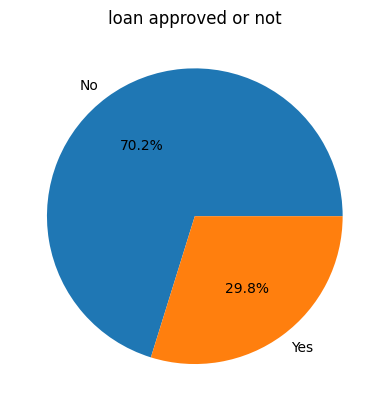

In [7]:
classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count , labels=["No" , "Yes"] , autopct= "%1.1f%%" )
plt.title("loan approved or not")

<Axes: xlabel='Applicant_Income', ylabel='Count'>

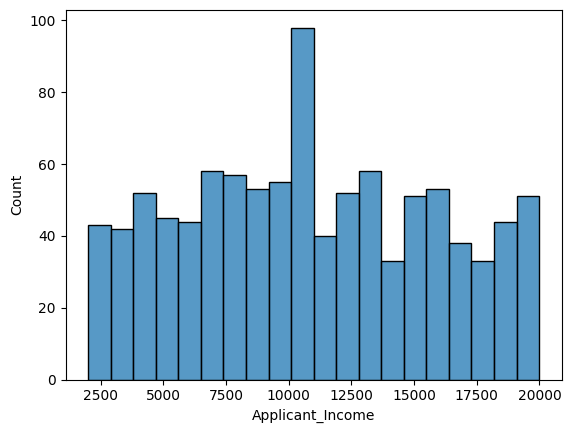

In [8]:
sns.histplot( data = df , x = "Applicant_Income" , bins = 20 )

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

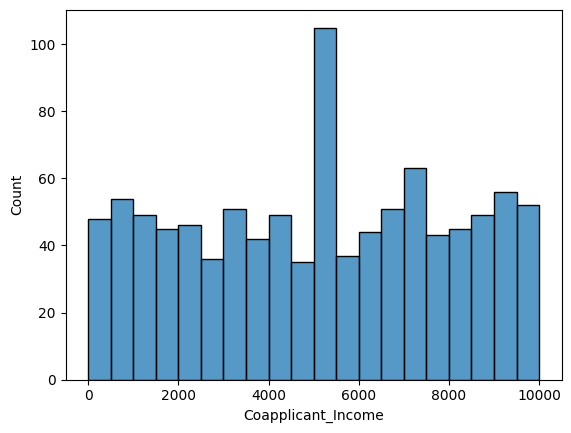

In [9]:
sns.histplot( data = df , x = "Coapplicant_Income" , bins = 20 )

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

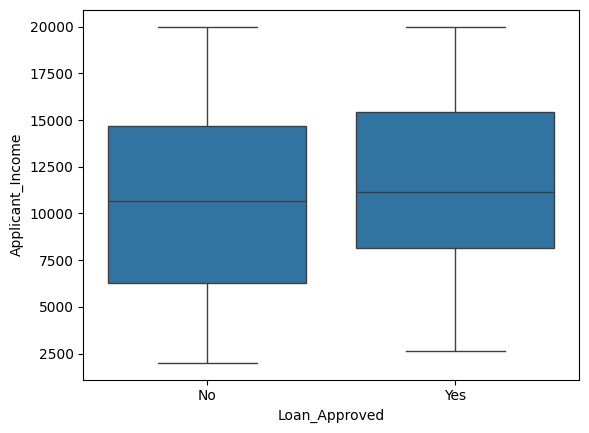

In [10]:
sns.boxplot( data = df , x = "Loan_Approved" , y = "Applicant_Income")

<Axes: xlabel='Credit_Score', ylabel='Count'>

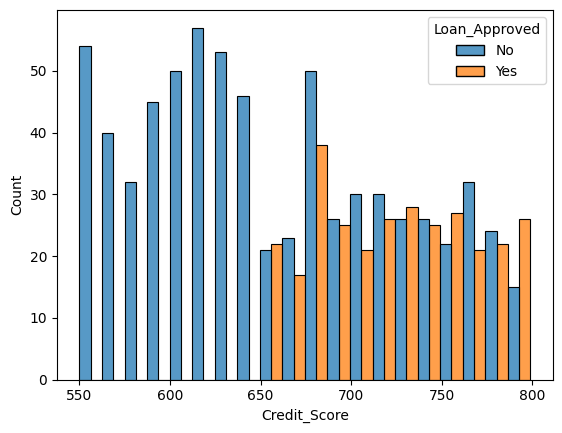

In [11]:
sns.histplot(data = df , x = "Credit_Score" , hue= "Loan_Approved", bins = 20 , multiple = "dodge")

In [12]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le = LabelEncoder()
# Encode Education_Level
df["Education_Level"] = le.fit_transform(df["Education_Level"])
# Encode Loan_Approved 
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [13]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [14]:
from sklearn.preprocessing import OneHotEncoder
cols = ["Employment_Status" , "Marital_Status" , "Loan_Purpose" , "Property_Area" , "Gender" , "Employer_Category"]
ohe = OneHotEncoder(drop="first",sparse_output=False, handle_unknown="ignore")
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded , columns =ohe.get_feature_names_out(cols))

In [15]:
ohe.get_feature_names_out(cols)

array(['Employment_Status_Salaried', 'Employment_Status_Self-employed',
       'Employment_Status_Unemployed', 'Marital_Status_Single',
       'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home',
       'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Gender_Male',
       'Employer_Category_Government', 'Employer_Category_MNC',
       'Employer_Category_Private', 'Employer_Category_Unemployed'],
      dtype=object)

In [16]:
encoded_df.head()

,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [17]:
df = pd.concat([df.drop(columns=cols) , encoded_df], axis = 1)

In [18]:
df.head()
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_ID                     1000 non-null   float64
 1   Applicant_Income                 1000 non-null   float64
 2   Coapplicant_Income               1000 non-null   float64
 3   Age                              1000 non-null   float64
 4   Dependents                       1000 non-null   float64
 5   Credit_Score                     1000 non-null   float64
 6   Existing_Loans                   1000 non-null   float64
 7   DTI_Ratio                        1000 non-null   float64
 8   Savings                          1000 non-null   float64
 9   Collateral_Value                 1000 non-null   float64
 10  Loan_Amount                      1000 non-null   float64
 11  Loan_Term                        1000 non-null   float64
 12  Education_Level      

In [21]:
nums_cols = df.select_dtypes(include="number")
corr_matrix = nums_cols.corr()

In [22]:
nums_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Applicant_ID                      -0.011167
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed    

<Axes: >

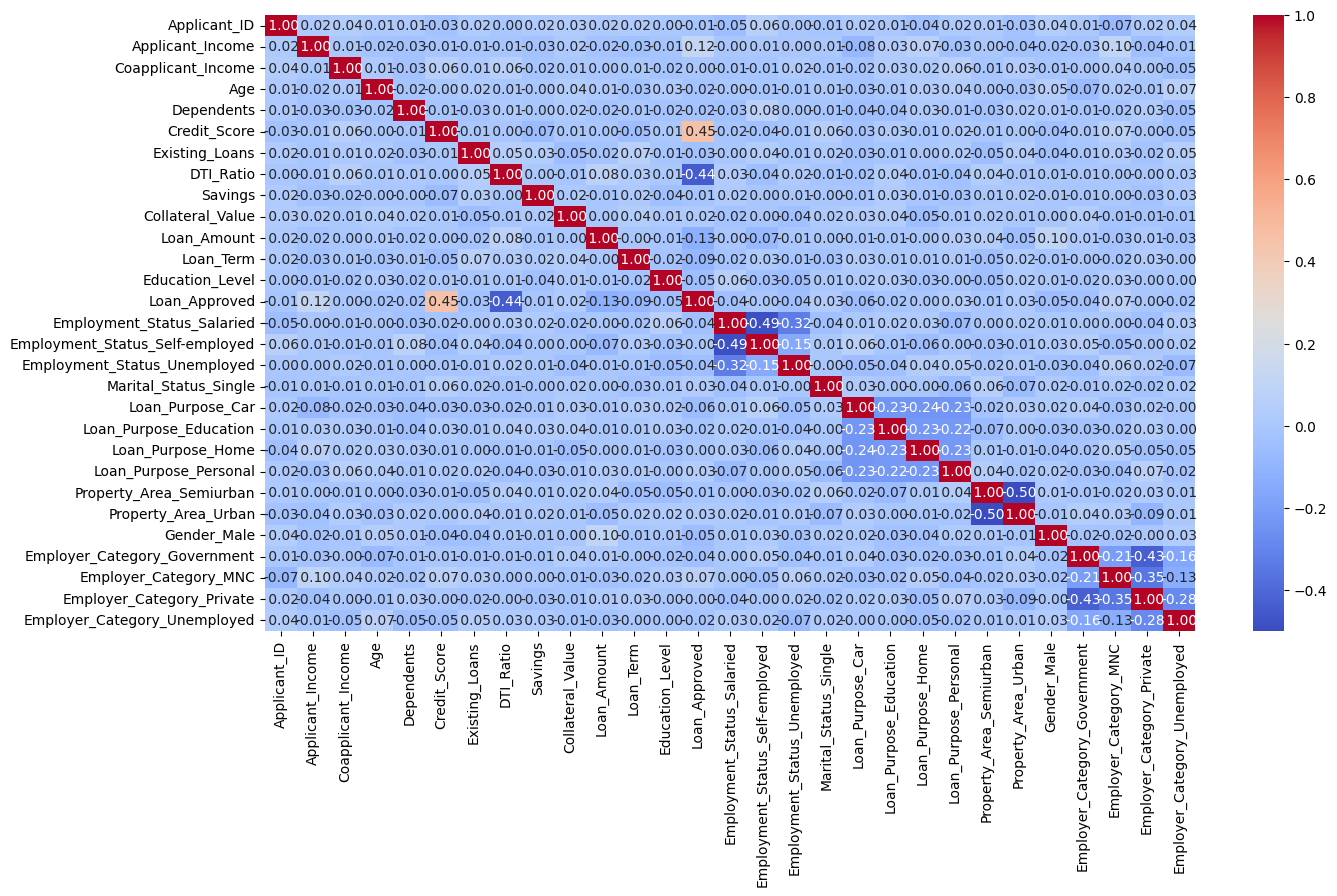

In [25]:
plt.figure(figsize = (15 , 8) )
sns.heatmap(
    corr_matrix ,
    annot = True ,
    fmt = " .2f" ,
    cmap = "coolwarm"
)

In [27]:
X = df.drop("Loan_Approved" , axis = 1)
y = df["Loan_Approved"]

In [29]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [32]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [33]:
X_test.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
521,522.0,13023.0,6675.0,53.000000,3.0,628.0,3.0,0.347263,10051.000000,26309.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
737,738.0,15917.0,6787.0,42.000000,0.0,588.0,4.0,0.410000,922.000000,13476.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
740,741.0,7560.0,3530.0,52.000000,3.0,606.0,0.0,0.580000,9940.452632,21795.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
660,661.0,19022.0,574.0,59.000000,0.0,725.0,4.0,0.410000,1463.000000,44498.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
411,412.0,4967.0,5797.0,39.971579,3.0,697.0,4.0,0.580000,1095.000000,3017.0,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
X_test_scaled

array([[ 0.07859054,  0.42610546,  0.55091079, ..., -0.41388776,
         1.16316   , -0.30723158],
       [ 0.84335174,  1.00971366,  0.58995935, ..., -0.41388776,
         1.16316   , -0.30723158],
       [ 0.85397342, -0.67557096, -0.54558674, ..., -0.41388776,
         1.16316   , -0.30723158],
       ...,
       [-1.02960507, -0.67980585, -0.10106072, ..., -0.41388776,
         1.16316   , -0.30723158],
       [ 0.40432216, -0.37650705, -0.97825874, ..., -0.41388776,
        -0.85972695, -0.30723158],
       [-1.48987801, -0.73647272, -1.24497436, ..., -0.41388776,
         1.16316   , -0.30723158]], shape=(200, 28))

Models 

In [42]:
#Linear Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix , accuracy_score , precision_score , recall_score , f1_score
log_model = LogisticRegression()
log_model.fit(X_train_scaled , y_train)
y_pred = log_model.predict(X_test_scaled)

#Evaluation
print("Precision :", precision_score(y_test, y_pred))
print("accuracy :", accuracy_score(y_test, y_pred))
print("recall :", recall_score(y_test, y_pred))
print("f1 :", f1_score(y_test, y_pred))
print("cm :", confusion_matrix(y_test, y_pred))


Precision : 0.7868852459016393
accuracy : 0.87
recall : 0.7868852459016393
f1 : 0.7868852459016393
cm : [[126  13]
 [ 13  48]]


In [49]:
#KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix , accuracy_score , precision_score , recall_score , f1_score
log_model = KNeighborsClassifier(n_neighbors= 6 )
log_model.fit(X_train_scaled , y_train)
y_pred = log_model.predict(X_test_scaled)

#Evaluation
print("Precision :", precision_score(y_test, y_pred))
print("accuracy :", accuracy_score(y_test, y_pred))
print("recall :", recall_score(y_test, y_pred))
print("f1 :", f1_score(y_test, y_pred))
print("cm :", confusion_matrix(y_test, y_pred))


Precision : 0.7142857142857143
accuracy : 0.755
recall : 0.32786885245901637
f1 : 0.449438202247191
cm : [[131   8]
 [ 41  20]]


In [52]:
#NaiveBayers

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix , accuracy_score , precision_score , recall_score , f1_score
log_model = GaussianNB()
log_model.fit(X_train_scaled , y_train)
y_pred = log_model.predict(X_test_scaled)

#Evaluation
print("Precision :", precision_score(y_test, y_pred))
print("accuracy :", accuracy_score(y_test, y_pred))
print("recall :", recall_score(y_test, y_pred))
print("f1 :", f1_score(y_test, y_pred))
print("cm :", confusion_matrix(y_test, y_pred))


Precision : 0.8035714285714286
accuracy : 0.865
recall : 0.7377049180327869
f1 : 0.7692307692307693
cm : [[128  11]
 [ 16  45]]
